In [1]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import torch, os
assert torch.cuda.is_available(), "GPU is off. Runtime > Change runtime type > select T4 GPU."

from google.colab import drive
drive.mount('/content/drive')
WORK = '/content/drive/MyDrive/SIH26142'
for d in ['', 'figures', 'outputs', 'tiles']:
    os.makedirs(f'{WORK}/{d}', exist_ok=True)

# ------------------------- CONFIG (final run) -------------------------
N_FINAL         = 1000          # SEN2VENUS pairs
EPOCHS_FINAL    = 60
BATCH           = 8
LR_INIT         = 2e-4
SCALE           = 2             # 10m -> 5m (SEN2VENUS's real supervision only goes this far)
LR_PATCH        = 48
HR_PATCH        = LR_PATCH * SCALE
PATCH_STRIDE_HR = 72            # smaller stride = more overlapping patches. Using 96 roughly halves epoch time but uses less data
FINAL_BANDS     = (1, 2, 3, 7)  # B2 Blue, B3 Green, B4 Red, B8 NIR (per SEN2VENUS's official band table)
print("Config set. Work dir:", WORK)


name, memory.total [MiB]
Tesla T4, 15360 MiB
Mounted at /content/drive
Config set. Work dir: /content/drive/MyDrive/SIH26142


In [2]:
!pip install -q timm einops rasterio scikit-image tacoreader tifffile
import subprocess, sys
if not os.path.exists('/content/SwinIR'):
    subprocess.run(['git', 'clone', '-q', 'https://github.com/JingyunLiang/SwinIR.git', '/content/SwinIR'], check=True)
if '/content/SwinIR' not in sys.path:
    sys.path.append('/content/SwinIR')
print("SwinIR repo ready:", os.path.exists('/content/SwinIR/models/network_swinir.py'))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 5.6 MB/s eta 0:00:00
SwinIR repo ready: True


In [3]:
import numpy as np, random, json, time
import rasterio
from rasterio.transform import Affine
from rasterio.windows import Window
import matplotlib.pyplot as plt
import torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from skimage.transform import resize
from skimage.filters import sobel
from tqdm.auto import tqdm
from models.network_swinir import SwinIR

device = 'cuda'
random.seed(42); np.random.seed(42); torch.manual_seed(42)

def extract_patches(hr_img, lr_img, hr_patch, scale, stride=None):
    stride = stride or hr_patch
    lr_patch = hr_patch // scale
    out = []
    h, w, _ = lr_img.shape
    for y in range(0, h - lr_patch + 1, stride // scale):
        for x in range(0, w - lr_patch + 1, stride // scale):
            lr_crop = lr_img[y:y+lr_patch, x:x+lr_patch]
            hr_crop = hr_img[y*scale:y*scale+hr_patch, x*scale:x*scale+hr_patch]
            if lr_crop.shape[:2] == (lr_patch, lr_patch) and hr_crop.shape[:2] == (hr_patch, hr_patch):
                out.append((lr_crop, hr_crop))
    return out

class PatchDataset(Dataset):
    """Augmentation (flip/rotate) applied only to the training set, freshly randomized every epoch."""
    def __init__(self, pairs, augment=False):
        self.pairs, self.augment = pairs, augment
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        lr, hr = self.pairs[i]
        if self.augment:
            if random.random() > 0.5: lr, hr = lr[:, ::-1], hr[:, ::-1]
            if random.random() > 0.5: lr, hr = lr[::-1], hr[::-1]
            k = random.randint(0, 3); lr, hr = np.rot90(lr, k), np.rot90(hr, k)
        lr = torch.from_numpy(np.ascontiguousarray(lr.transpose(2, 0, 1))).float()
        hr = torch.from_numpy(np.ascontiguousarray(hr.transpose(2, 0, 1))).float()
        return lr, hr

print("Helpers ready.")


Helpers ready.


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
import tacoreader.v1 as tacoreader
from concurrent.futures import ThreadPoolExecutor
from collections import Counter

dataset = tacoreader.load("tacofoundation:sen2venus")
try:
    idxs = random.Random(42).sample(range(len(dataset)), N_FINAL)   # random sample across sites, not just the first N
except Exception:
    idxs = list(range(N_FINAL))

CACHE = f'{WORK}/cache_pairs_{N_FINAL}.npz'

def read_raw(path):
    with rasterio.open(path) as src:
        return src.read(list(FINAL_BANDS))       # uint16, (C,H,W)

def load_pair(p, tries=3):
    for k in range(tries):
        try:
            return read_raw(p[0]), read_raw(p[1])
        except Exception:
            time.sleep(2 * (k + 1))
    return None

if os.path.exists(CACHE):
    z = np.load(CACHE)
    raw_lr, raw_hr, kept_idx = z['lr'], z['hr'], z['kept_idx']
    print("Loaded from cache.")
else:
    paths = []
    for i in tqdm(idxs, desc="Reading dataset rows"):
        row = dataset.read(i); paths.append((row.read(0), row.read(1)))
    with ThreadPoolExecutor(6) as ex:                # reduce 6 to 2 if you hit rate-limit/errors
        results = list(tqdm(ex.map(load_pair, paths), total=len(paths), desc="Downloading pairs"))
    good = [(k, r) for k, r in enumerate(results)
            if r is not None and r[0].max() > 0 and r[1].max() > 0
            and r[1].shape[1] == SCALE * r[0].shape[1] and r[1].shape[2] == SCALE * r[0].shape[2]]
    mode_shape = Counter(r[0].shape for _, r in good).most_common(1)[0][0]
    good = [(k, r) for k, r in good if r[0].shape == mode_shape]
    print(f"Kept {len(good)}/{len(idxs)} pairs (shape {mode_shape})")
    raw_lr = np.stack([r[0] for _, r in good]); raw_hr = np.stack([r[1] for _, r in good])
    kept_idx = np.array([idxs[k] for k, _ in good])
    np.savez_compressed(CACHE, lr=raw_lr, hr=raw_hr, kept_idx=kept_idx)
print("LR:", raw_lr.shape, "| HR:", raw_hr.shape)


Loaded from cache.
LR: (826, 4, 128, 128) | HR: (826, 4, 256, 256)


In [5]:
from sklearn.model_selection import train_test_split

idx_all = np.arange(len(raw_lr))
tr, tmp = train_test_split(idx_all, test_size=0.30, random_state=42)
va, te  = train_test_split(tmp, test_size=0.50, random_state=42)
print(f"Train {len(tr)} | Val {len(va)} | Test {len(te)}")

def band_p995(raw):
    sub = raw.transpose(1, 0, 2, 3).reshape(raw.shape[1], -1)[:, ::50].astype(np.float32)
    return np.percentile(sub, 99.5, axis=1)

BAND_SCALE = (np.ceil(band_p995(raw_lr[tr]) / 100) * 100).astype(np.float32)
print("BAND_SCALE (B,G,R,NIR):", BAND_SCALE)
print("HR train 99.5th pct (sanity check, should be close to LR):", np.round(band_p995(raw_hr[tr])))

def norm(raw):
    return np.clip(raw.astype(np.float32).transpose(0, 2, 3, 1) / BAND_SCALE, 0, 1)

lr_all, hr_all = norm(raw_lr), norm(raw_hr)
del raw_lr, raw_hr

def make_patches(ids):
    out = []
    for i in ids:
        out.extend(extract_patches(hr_all[i], lr_all[i], HR_PATCH, SCALE, stride=PATCH_STRIDE_HR))
    return out

train_patches = make_patches(tr)
val_patches   = make_patches(va)
print("Train patches:", len(train_patches), "| Val patches:", len(val_patches))

eval_lr, eval_hr = lr_all[te], hr_all[te]          # held-out TEST images (full tiles, 4-channel)


Train 578 | Val 124 | Test 124
BAND_SCALE (B,G,R,NIR): [1400. 2100. 3100. 5000.]
HR train 99.5th pct (sanity check, should be close to LR): [1387. 2063. 3087. 4753.]
Train patches: 5202 | Val patches: 1116


In [6]:
model = SwinIR(upscale=SCALE, in_chans=4, img_size=LR_PATCH, window_size=8, img_range=1.,
               depths=[6,6,6,6], embed_dim=60, num_heads=[6,6,6,6], mlp_ratio=2,
               upsampler='pixelshuffledirect', resi_connection='1conv').to(device)
optimizer = optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINAL, eta_min=1e-6)
criterion = nn.L1Loss()

train_loader = DataLoader(PatchDataset(train_patches, augment=True), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(PatchDataset(val_patches, augment=False), batch_size=BATCH, shuffle=False)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total = 0.0
    with (torch.enable_grad() if train else torch.no_grad()):
        for lr, hr in loader:
            lr, hr = lr.to(device), hr.to(device)
            if train: optimizer.zero_grad()
            loss = criterion(model(lr), hr)
            if train:
                loss.backward(); optimizer.step()
            total += loss.item()
    return total / len(loader)

CKPT_BEST = f'{WORK}/swinir_4ch_best.pth'
CKPT_LAST = f'{WORK}/swinir_4ch_last.pt'
CFG = dict(N=len(idx_all), epochs=EPOCHS_FINAL, scale=SCALE, bands=list(FINAL_BANDS), stride=PATCH_STRIDE_HR)

start_epoch, best, history = 0, float('inf'), {"train_loss": [], "val_loss": []}
if os.path.exists(CKPT_LAST):
    ck = torch.load(CKPT_LAST, map_location=device, weights_only=False)
    if ck.get('cfg') == CFG:
        model.load_state_dict(ck['model']); optimizer.load_state_dict(ck['opt']); scheduler.load_state_dict(ck['sched'])
        start_epoch, best, history = ck['epoch'] + 1, ck['best'], ck['history']
        print(f"Resuming from epoch {start_epoch}/{EPOCHS_FINAL}")
    else:
        print("Existing checkpoint has a different config, ignoring it. Starting fresh training.")

for epoch in range(start_epoch, EPOCHS_FINAL):
    t0 = time.time()
    tl = run_epoch(train_loader, True); vl = run_epoch(val_loader, False); scheduler.step()
    history["train_loss"].append(tl); history["val_loss"].append(vl)
    improved = vl < best
    if improved:
        best = vl; torch.save(model.state_dict(), CKPT_BEST)
    torch.save(dict(model=model.state_dict(), opt=optimizer.state_dict(), sched=scheduler.state_dict(),
                    epoch=epoch, best=best, history=history, cfg=CFG), CKPT_LAST)
    print(f"Epoch {epoch+1}/{EPOCHS_FINAL} | train {tl:.4f} | val {vl:.4f} | {time.time()-t0:.0f}s{'  <- best' if improved else ''}")

json.dump(history, open(f'{WORK}/history.json', 'w'))
model.load_state_dict(torch.load(CKPT_BEST, map_location=device)); model.eval()
print("Best val loss:", round(best, 5), "| best checkpoint loaded.")


/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Resuming from epoch 60/60
Best val loss: 0.02217 | best checkpoint loaded.


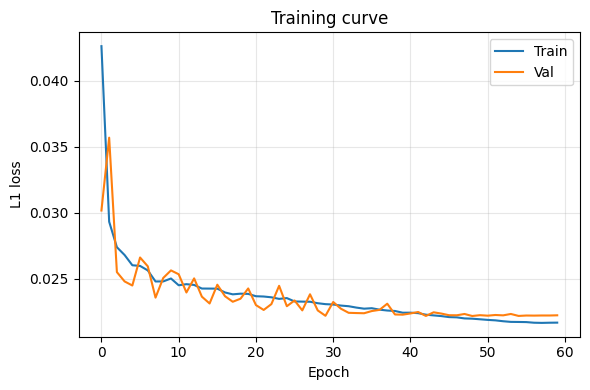

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="Train"); plt.plot(history["val_loss"], label="Val")
plt.xlabel("Epoch"); plt.ylabel("L1 loss"); plt.title("Training curve"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f'{WORK}/figures/training_curve.png', dpi=150); plt.show()


In [8]:
@torch.no_grad()
def sr2x_tiled(net, img_hwc, patch=48, margin=4, batch=16):
    """(H,W,C) [0,1] -> (2H,2W,C)."""
    net.eval(); s = 2
    h, w, c = img_hwc.shape
    core = patch - 2 * margin
    ny, nx = -(-h // core), -(-w // core)
    P = np.pad(img_hwc, ((margin, ny*core + margin - h), (margin, nx*core + margin - w), (0, 0)), mode='reflect')
    out = np.zeros((ny*core*s, nx*core*s, c), np.float32)
    coords = [(y*core, x*core) for y in range(ny) for x in range(nx)]
    for i in range(0, len(coords), batch):
        chunk = coords[i:i+batch]
        t = torch.from_numpy(np.stack([P[y:y+patch, x:x+patch] for y, x in chunk]).transpose(0,3,1,2)).float().to(device)
        sr = net(t).clamp(0, 1).cpu().numpy().transpose(0,2,3,1)
        for (y, x), p in zip(chunk, sr):
            out[y*s:(y+core)*s, x*s:(x+core)*s] = p[margin*s:(patch-margin)*s, margin*s:(patch-margin)*s]
    return out[:h*s, :w*s]

def cascade_tile(net, img_hwc, steps=2):
    outs, cur = [], img_hwc
    for _ in range(steps):
        cur = sr2x_tiled(net, cur); outs.append(cur)
    return outs        # [5m, 2.5m]

def tile_uncertainty(net, img):
    """Stage-1 (5m) TTA uncertainty: std across 4 flips. (Stage-2 uncertainty is not computed here -- note this explicitly in the report.)"""
    preds = []
    for fy in (False, True):
        for fx in (False, True):
            x = img[::-1] if fy else img
            x = x[:, ::-1] if fx else x
            p = sr2x_tiled(net, np.ascontiguousarray(x))
            p = p[:, ::-1] if fx else p
            p = p[::-1] if fy else p
            preds.append(p)
    preds = np.stack(preds)
    return preds.mean(0), preds.std(0).mean(-1)

def ndvi_dn(img_hwc, eps=1e-6):
    d = img_hwc * BAND_SCALE                      # channel order B,G,R,NIR
    return (d[..., 3] - d[..., 2]) / (d[..., 3] + d[..., 2] + eps)

def sam_deg(a, b, eps=1e-8):
    """Spectral Angle Mapper (degrees); lower = better spectral consistency."""
    a = (a * BAND_SCALE).reshape(-1, a.shape[-1]); b = (b * BAND_SCALE).reshape(-1, b.shape[-1])
    cos = (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + eps)
    return float(np.degrees(np.arccos(np.clip(cos, -1, 1))).mean())

def bicubic_up(img, f):
    h, w, c = img.shape
    return np.clip(resize(img, (h*f, w*f, c), order=3, mode='edge', anti_aliasing=False), 0, 1)

def block_down(img, f):
    h, w, c = img.shape
    return img.reshape(h//f, f, w//f, f, c).mean((1, 3))

def rgb_disp(img, ref=None):
    """B,G,R channels -> R,G,B for display (percentile stretch computed from `ref` so panels stay comparable)."""
    ref = img if ref is None else ref
    r = ref[..., [2,1,0]]; lo, hi = np.percentile(r, 2), np.percentile(r, 98)
    return np.clip((img[..., [2,1,0]] - lo) / (hi - lo + 1e-6), 0, 1)

print("Inference tools ready.")


Inference tools ready.


In [9]:
def metrics(hr, out):
    hh, ww = min(hr.shape[0], out.shape[0]), min(hr.shape[1], out.shape[1])
    a, b = hr[:hh, :ww], out[:hh, :ww]
    return dict(PSNR=psnr(a, b, data_range=1.0), SSIM=ssim(a, b, channel_axis=-1, data_range=1.0),
                RMSE=float(np.sqrt(np.mean((a - b) ** 2))),
                NDVI_MAE=float(np.mean(np.abs(ndvi_dn(a) - ndvi_dn(b)))), SAM_deg=sam_deg(a, b))

rows = {"Bicubic 2x": [], "SwinIR 2x (stage-1, 5m)": []}
cons = {"Bicubic 4x": [], "Cascade 2x+2x (2.5m)": []}
for lr, hr in tqdm(list(zip(eval_lr, eval_hr)), desc="Test eval"):
    st1, st2 = cascade_tile(model, lr, 2)
    rows["Bicubic 2x"].append(metrics(hr, bicubic_up(lr, 2)))
    rows["SwinIR 2x (stage-1, 5m)"].append(metrics(hr, st1))
    cons["Bicubic 4x"].append(float(np.sqrt(np.mean((block_down(bicubic_up(lr, 4), 4) - lr) ** 2))))
    cons["Cascade 2x+2x (2.5m)"].append(float(np.sqrt(np.mean((block_down(st2, 4) - lr) ** 2))))

summary = {k: {m: (float(np.mean([r[m] for r in v])), float(np.std([r[m] for r in v]))) for m in v[0]} for k, v in rows.items()}
cons_summary = {k: (float(np.mean(v)), float(np.std(v))) for k, v in cons.items()}

print(f"=== TEST SET ({len(eval_lr)} tiles), 5m stage vs REAL VENUS ground truth (mean +- std) ===")
print(f"{'Method':<26}{'PSNR (dB)':>16}{'SSIM':>16}{'RMSE':>16}{'NDVI-MAE':>16}{'SAM (deg)':>16}")
for k, m in summary.items():
    print(f"{k:<26}" + "".join(f"{m[c][0]:>10.4f}+-{m[c][1]:.3f}" for c in ["PSNR", "SSIM", "RMSE", "NDVI_MAE", "SAM_deg"]))
print("\n=== 2.5m stage: LR-consistency RMSE (lower = better). NOTE: no real 2.5m ground truth exists; this is extrapolated ===")
for k, (m, s) in cons_summary.items():
    print(f"{k:<26}{m:.5f} +- {s:.5f}")

json.dump(dict(stage1_vs_real_HR=summary, lr_consistency_2p5m=cons_summary, n_test=len(eval_lr),
               band_scale=BAND_SCALE.tolist(), best_val_loss=best), open(f'{WORK}/final_results.json', 'w'), indent=2)
print(f"\nSaved: {WORK}/final_results.json")


Test eval:   0%|          | 0/124 [00:00<?, ?it/s]

=== TEST SET (124 tiles), 5m stage vs REAL VENUS ground truth (mean +- std) ===
Method                           PSNR (dB)            SSIM            RMSE        NDVI-MAE       SAM (deg)
Bicubic 2x                   29.6168+-2.923    0.8877+-0.056    0.0349+-0.011    0.0286+-0.023    1.7214+-0.894
SwinIR 2x (stage-1, 5m)      30.2572+-2.749    0.8980+-0.053    0.0322+-0.010    0.0290+-0.033    1.6630+-1.067

=== 2.5m stage: LR-consistency RMSE (lower = better). NOTE: no real 2.5m ground truth exists; this is extrapolated ===
Bicubic 4x                0.00553 +- 0.00202
Cascade 2x+2x (2.5m)      0.02419 +- 0.00658

Saved: /content/drive/MyDrive/SIH26142/final_results.json


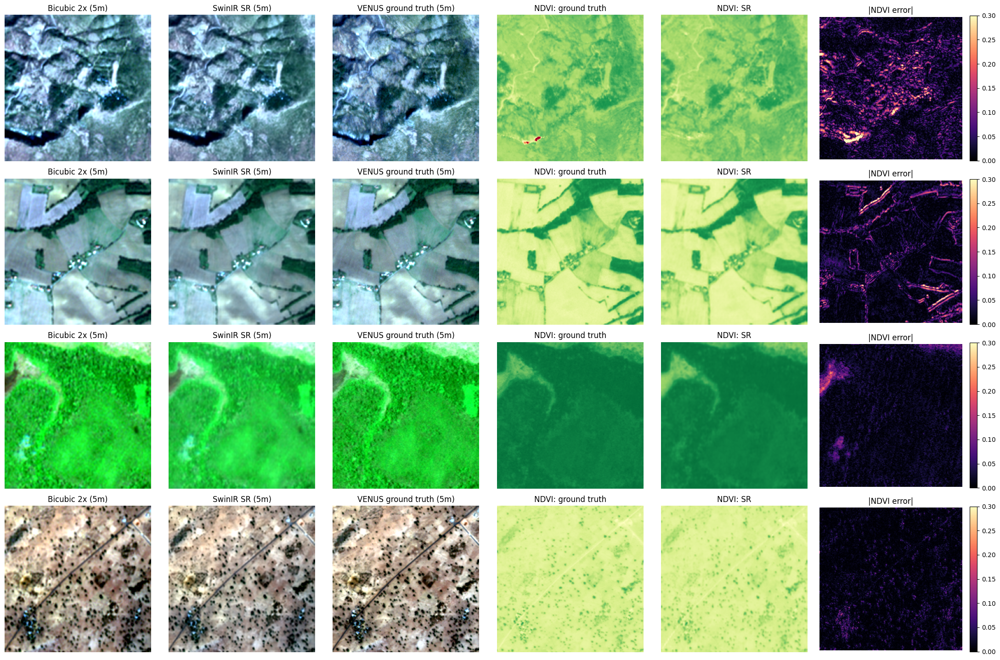

In [10]:
# Qualitative figure (for the report/slides): bicubic vs SR vs HR, plus NDVI comparison
def qual_figure(test_ids, fname):
    fig, ax = plt.subplots(len(test_ids), 6, figsize=(22, 3.6 * len(test_ids)), squeeze=False)
    for r, k in enumerate(test_ids):
        lr, hr = eval_lr[k], eval_hr[k]
        bc, sr = bicubic_up(lr, 2), sr2x_tiled(model, lr)
        nh, ns = ndvi_dn(hr), ndvi_dn(sr)
        ax[r,0].imshow(rgb_disp(bc, hr)); ax[r,0].set_title("Bicubic 2x (5m)")
        ax[r,1].imshow(rgb_disp(sr, hr));  ax[r,1].set_title("SwinIR SR (5m)")
        ax[r,2].imshow(rgb_disp(hr, hr));  ax[r,2].set_title("VENUS ground truth (5m)")
        ax[r,3].imshow(nh, cmap='RdYlGn', vmin=-1, vmax=1); ax[r,3].set_title("NDVI: ground truth")
        ax[r,4].imshow(ns, cmap='RdYlGn', vmin=-1, vmax=1); ax[r,4].set_title("NDVI: SR")
        im = ax[r,5].imshow(np.abs(ns - nh), cmap='magma', vmin=0, vmax=0.3); ax[r,5].set_title("|NDVI error|")
        for a in ax[r]: a.axis('off')
        plt.colorbar(im, ax=ax[r,5], fraction=0.046)
    plt.tight_layout(); plt.savefig(f'{WORK}/figures/{fname}', dpi=150); plt.show()

qual_figure(list(range(min(4, len(eval_lr)))), 'qualitative_test.png')


Correlation(TTA uncertainty, actual |error|) over 20 test tiles: 0.252 +- 0.128
(Positive = the model tends to be more wrong exactly where it is more uncertain. Report this value honestly.)


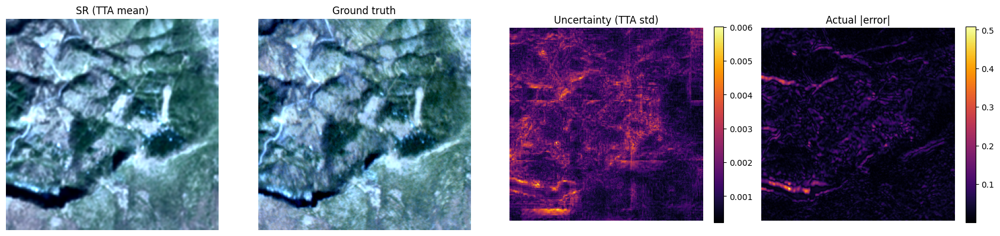

In [11]:
corrs = []
for k in range(min(20, len(eval_lr))):
    mean_sr, u = tile_uncertainty(model, eval_lr[k])
    err = np.abs(mean_sr - eval_hr[k]).mean(-1)
    corrs.append(np.corrcoef(u.ravel(), err.ravel())[0, 1])
print(f"Correlation(TTA uncertainty, actual |error|) over {len(corrs)} test tiles: {np.nanmean(corrs):.3f} +- {np.nanstd(corrs):.3f}")
print("(Positive = the model tends to be more wrong exactly where it is more uncertain. Report this value honestly.)")

k = 0
mean_sr, u = tile_uncertainty(model, eval_lr[k]); err = np.abs(mean_sr - eval_hr[k]).mean(-1)
fig, ax = plt.subplots(1, 4, figsize=(17, 4))
ax[0].imshow(rgb_disp(mean_sr, eval_hr[k])); ax[0].set_title("SR (TTA mean)")
ax[1].imshow(rgb_disp(eval_hr[k], eval_hr[k])); ax[1].set_title("Ground truth")
i1 = ax[2].imshow(u, cmap='inferno'); ax[2].set_title("Uncertainty (TTA std)"); plt.colorbar(i1, ax=ax[2], fraction=.046)
i2 = ax[3].imshow(err, cmap='inferno'); ax[3].set_title("Actual |error|"); plt.colorbar(i2, ax=ax[3], fraction=.046)
for a in ax: a.axis('off')
plt.tight_layout(); plt.savefig(f'{WORK}/figures/uncertainty.png', dpi=150); plt.show()


In [12]:
def read_tile(path, bands=(1,2,3,4), win=None):
    """win = (x0, y0, size) or None. If a Copernicus export is in 0-1 reflectance, it is rescaled by 10000."""
    with rasterio.open(path) as src:
        if win is None:
            w = Window(0, 0, src.width, src.height)
        else:
            x0, y0, s = win; w = Window(x0, y0, min(s, src.width - x0), min(s, src.height - y0))
        arr = src.read(list(bands), window=w).astype(np.float32)
        crs, tf = src.crs, src.window_transform(w)
    if arr.max() <= 5:
        arr = arr * 10000.0
    return np.clip(arr.transpose(1, 2, 0) / BAND_SCALE, 0, 1), crs, tf

def run_cascade_geotiff(net, tile_path, out_path, bands=(1,2,3,4), steps=2, win=None):
    img, crs, tf = read_tile(tile_path, bands, win)
    outs = cascade_tile(net, img, steps)
    f = 2 ** steps
    dn = (outs[-1] * BAND_SCALE).astype(np.float32).transpose(2, 0, 1)      # float32, original DN units
    with rasterio.open(out_path, 'w', driver='GTiff', height=dn.shape[1], width=dn.shape[2], count=dn.shape[0],
                       dtype='float32', crs=crs, transform=tf * Affine.scale(1 / f, 1 / f)) as dst:
        dst.write(dn)
    return img, outs, crs, tf

def verify_sr_georef(img, crs, tf, sr_path, f, tol=1e-6):
    with rasterio.open(sr_path) as sr:
        print(f"CRS: {crs} -> {sr.crs}")
        print(f"Pixel size: {abs(tf.a):.4f} -> {abs(sr.transform.a):.4f} | Origin: ({tf.c:.2f},{tf.f:.2f}) -> ({sr.transform.c:.2f},{sr.transform.f:.2f})")
        assert sr.crs == crs, "CRS mismatch"
        assert abs(sr.transform.a - tf.a / f) < tol * max(1, abs(tf.a)), "Pixel size scale is wrong"
        assert abs(sr.transform.c - tf.c) < 1e-3 and abs(sr.transform.f - tf.f) < 1e-3, "Origin shifted"
        assert sr.width == img.shape[1] * f and sr.height == img.shape[0] * f, "Output dimensions are wrong"
    print("Georeferencing PASSED: CRS same, pixel size / f, origin same, footprint same.")

def aoi_demo(name, tile_path, bands=(1,2,3,4), win=(0, 0, 256), with_uncertainty=True):
    out_path = f"{WORK}/outputs/{name}_SR_2p5m.tif"
    img, outs, crs, tf = run_cascade_geotiff(model, tile_path, out_path, bands, win=win)
    st2 = outs[-1]; bc4 = bicubic_up(img, 4)
    verify_sr_georef(img, crs, tf, out_path, 4)
    print(f"LR-consistency RMSE -> Cascade: {np.sqrt(np.mean((block_down(st2,4)-img)**2)):.5f} | Bicubic: {np.sqrt(np.mean((block_down(bc4,4)-img)**2)):.5f}")
    e_bc, e_sr = sobel(bc4[..., :3].mean(-1)), sobel(st2[..., :3].mean(-1))
    n_bc, n_sr = ndvi_dn(bc4), ndvi_dn(st2)
    print(f"Mean edge strength -> Bicubic: {e_bc.mean():.5f} | SR: {e_sr.mean():.5f} (feature visibility only, not proof of accuracy)")
    print(f"NDVI mean -> Bicubic: {n_bc.mean():.3f} | SR: {n_sr.mean():.3f}")
    fig, ax = plt.subplots(2, 4, figsize=(18, 9))
    ax[0,0].imshow(rgb_disp(bc4, bc4)); ax[0,0].set_title("Bicubic 4x (2.5m)")
    ax[0,1].imshow(rgb_disp(st2, bc4)); ax[0,1].set_title("Cascade SR (2.5m)")
    ax[0,2].imshow(e_bc, cmap='gray'); ax[0,2].set_title("Edges: bicubic")
    ax[0,3].imshow(e_sr, cmap='gray'); ax[0,3].set_title("Edges: SR")
    ax[1,0].imshow(n_bc, cmap='RdYlGn', vmin=-1, vmax=1); ax[1,0].set_title("NDVI: bicubic")
    ax[1,1].imshow(n_sr, cmap='RdYlGn', vmin=-1, vmax=1); ax[1,1].set_title("NDVI: SR")
    ax[1,2].imshow(n_sr - n_bc, cmap='coolwarm', vmin=-0.3, vmax=0.3); ax[1,2].set_title("NDVI: SR - bicubic")
    if with_uncertainty:
        _, u = tile_uncertainty(model, img)
        im = ax[1,3].imshow(u, cmap='inferno'); ax[1,3].set_title("Uncertainty (stage-1 TTA std)"); plt.colorbar(im, ax=ax[1,3], fraction=.046)
    for a in ax.ravel(): a.axis('off')
    plt.suptitle(name); plt.tight_layout(); plt.savefig(f'{WORK}/figures/aoi_{name}.png', dpi=150); plt.show()
    return out_path

def inspect_tile(path):
    with rasterio.open(path) as src:
        print(f"{os.path.basename(path)} | bands {src.count} | size {src.width}x{src.height} | res {src.res} | crs {src.crs} | dtype {src.dtypes[0]}")
        for b in range(1, min(src.count, 6) + 1):
            a = src.read(b, window=Window(0, 0, min(512, src.width), min(512, src.height))).astype(np.float32)
            print(f"  band {b}: mean {a.mean():.1f}, p99 {np.percentile(a, 99):.1f}")
    print("  Confirm band order: should be B02,B03,B04,B08 (B,G,R,NIR). NIR mean should be noticeably higher than Red (vegetation).")

def stack_bands(b02, b03, b04, b08, out_path):
    """Combines separate Copernicus band files into a single 4-band GeoTIFF (B,G,R,NIR)."""
    arrs = []
    for p in (b02, b03, b04, b08):
        with rasterio.open(p) as s:
            arrs.append(s.read(1)); prof = s.profile.copy()
    prof.update(count=4, dtype=arrs[0].dtype)
    with rasterio.open(out_path, 'w', **prof) as dst:
        for i, a in enumerate(arrs, 1): dst.write(a, i)
    return out_path

print("Phase 5 tools ready.")


Phase 5 tools ready.


CRS: EPSG:32631 -> EPSG:32631
Pixel size: 10.0000 -> 2.5000 | Origin: (316410.00,4701375.00) -> (316410.00,4701375.00)
Georeferencing PASSED: CRS same, pixel size / f, origin same, footprint same.
LR-consistency RMSE -> Cascade: 0.02017 | Bicubic: 0.00472
Mean edge strength -> Bicubic: 0.01699 | SR: 0.01386 (feature visibility only, not proof of accuracy)
NDVI mean -> Bicubic: 0.493 | SR: 0.506


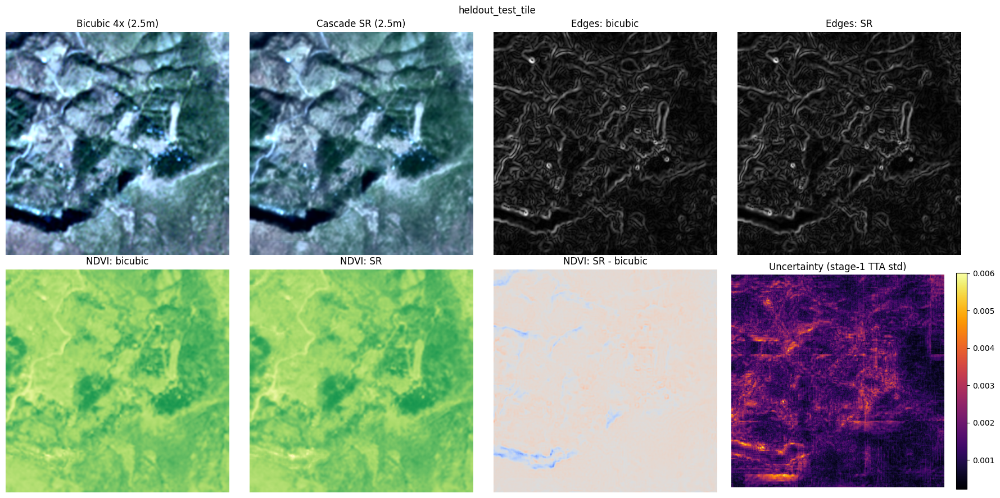

In [13]:
# Held-out SEN2VENUS test tile: a real georeferenced file, run through the full pipeline (cascade + GeoTIFF + georeference check + uncertainty)
row = dataset.read(int(kept_idx[te[0]]))
_ = aoi_demo("heldout_test_tile", row.read(0), bands=FINAL_BANDS, win=None)


In [14]:
# Supplementary statistical validation: paired significance test against bicubic, per-band error
# breakdown, and the VENUS-vs-Sentinel-2 sensor floor referenced in the report.
rms = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
KEYS = ["PSNR", "SSIM", "RMSE", "NDVI_MAE", "SAM_deg"]
M = {k: {"Bicubic": [], "SwinIR": [], "SwinIR+TTA": []} for k in KEYS}
floor, c1, c2 = [], [], []
pb = {"Bicubic": [], "SwinIR": []}

for lr, hr in tqdm(list(zip(eval_lr, eval_hr)), desc="Diagnostics"):
    st1, st2 = cascade_tile(model, lr, 2)
    tta, _ = tile_uncertainty(model, lr)
    bc = bicubic_up(lr, 2)
    for name, out in [("Bicubic", bc), ("SwinIR", st1), ("SwinIR+TTA", tta)]:
        m = metrics(hr, out)
        for k in KEYS: M[k][name].append(m[k])
    pb["Bicubic"].append(np.sqrt(((bc - hr) ** 2).mean((0, 1))))
    pb["SwinIR"].append(np.sqrt(((st1 - hr) ** 2).mean((0, 1))))
    floor.append(rms(block_down(hr, 2), lr))       # gap between real VENUS HR and its own LR (sensor floor)
    c1.append(rms(block_down(st1, 2), lr))
    c2.append(rms(block_down(st2, 4), lr))

print("=== Paired: method - Bicubic (95% CI, and % of tiles where the method wins) ===")
for k in KEYS:
    for name in ["SwinIR", "SwinIR+TTA"]:
        d = np.array(M[k][name]) - np.array(M[k]["Bicubic"])
        lower_better = k in ("RMSE", "NDVI_MAE", "SAM_deg")
        win = np.mean(d < 0) if lower_better else np.mean(d > 0)
        se = d.std(ddof=1) / np.sqrt(len(d))
        print(f"{k:<9}{name:<12} {d.mean():+.4f}  CI [{d.mean()-1.96*se:+.4f}, {d.mean()+1.96*se:+.4f}]  better on {win*100:.0f}% tiles")

print("\n=== Per-band RMSE vs real HR (B, G, R, NIR) ===")
for n in pb: print(f"{n:<8}", np.round(np.mean(pb[n], 0), 4))

print("\n=== LR-consistency RMSE (after averaging back down to 10m) ===")
print(f"Real VENUS HR itself     : {np.mean(floor):.5f}   <- sensor-difference floor")
print(f"SwinIR stage-1 (5m)      : {np.mean(c1):.5f}")
print(f"Cascade 2.5m             : {np.mean(c2):.5f}")

json.dump(dict(paired={k: {n: float(np.mean(M[k][n])) for n in M[k]} for k in KEYS},
               floor=float(np.mean(floor)), stage1=float(np.mean(c1)), cascade=float(np.mean(c2))),
          open(f'{WORK}/extra_diagnostics.json', 'w'), indent=2)

Diagnostics:   0%|          | 0/124 [00:00<?, ?it/s]

=== Paired: method - Bicubic (95% CI, and % of tiles where the method wins) ===
PSNR     SwinIR       +0.6404  CI [+0.5188, +0.7620]  better on 85% tiles
PSNR     SwinIR+TTA   +0.6505  CI [+0.5291, +0.7720]  better on 84% tiles
SSIM     SwinIR       +0.0104  CI [+0.0083, +0.0124]  better on 90% tiles
SSIM     SwinIR+TTA   +0.0108  CI [+0.0088, +0.0128]  better on 90% tiles
RMSE     SwinIR       -0.0027  CI [-0.0031, -0.0022]  better on 85% tiles
RMSE     SwinIR+TTA   -0.0027  CI [-0.0032, -0.0022]  better on 84% tiles
NDVI_MAE SwinIR       +0.0004  CI [-0.0017, +0.0025]  better on 69% tiles
NDVI_MAE SwinIR+TTA   +0.0003  CI [-0.0019, +0.0024]  better on 69% tiles
SAM_deg  SwinIR       -0.0584  CI [-0.1127, -0.0041]  better on 73% tiles
SAM_deg  SwinIR+TTA   -0.0638  CI [-0.1182, -0.0095]  better on 73% tiles

=== Per-band RMSE vs real HR (B, G, R, NIR) ===
Bicubic  [0.0402 0.0323 0.0273 0.0361]
SwinIR   [0.0366 0.0293 0.0259 0.0339]

=== LR-consistency RMSE (after averaging back down t

In [16]:
import glob

def find_band(folder, band):
    matches = glob.glob(f"{folder}/*_{band}_10m.jp2")
    assert len(matches) == 1, f"{band}: found {len(matches)} files in {folder} (expected 1)"
    return matches[0]

In [17]:
from rasterio.windows import Window

def stack_bands_fixed(b02, b03, b04, b08, out_path, size=512):
    arrs = []
    for p in (b02, b03, b04, b08):
        with rasterio.open(p) as s:
            w = Window(0, 0, min(size, s.width), min(size, s.height))
            arrs.append(s.read(1, window=w))
            if p == b02:
                crs, tf, dt = s.crs, s.window_transform(w), s.dtypes[0]
    with rasterio.open(out_path, 'w', driver='GTiff', height=arrs[0].shape[0], width=arrs[0].shape[1],
                       count=4, dtype=dt, crs=crs, transform=tf) as dst:
        for i, a in enumerate(arrs, 1):
            dst.write(a, i)
    return out_path

paths = {}
for name in ["urban", "agri", "water"]:
    folder = f"{WORK}/tiles/{name}_raw"
    out_path = f"{WORK}/tiles/{name}.tif"
    if os.path.exists(folder):
        b02, b03, b04, b08 = [find_band(folder, b) for b in ("B02", "B03", "B04", "B08")]
        stack_bands_fixed(b02, b03, b04, b08, out_path)
        with rasterio.open(out_path) as s:
            print(name, "-> driver:", s.driver, "| size:", s.width, s.height)
        paths[name] = out_path
    else:
        print(f"[skip] {folder} not found")

urban -> driver: GTiff | size: 512 512
agri -> driver: GTiff | size: 512 512
water -> driver: GTiff | size: 512 512


In [18]:
for name in ["urban", "agri", "water"]:
    p = f"{WORK}/tiles/{name}.tif"
    if os.path.exists(p):
        inspect_tile(p)
        print()

urban.tif | bands 4 | size 512x512 | res (10.0, 10.0) | crs EPSG:32750 | dtype uint16
  band 1: mean 1993.5, p99 2758.0
  band 2: mean 2405.6, p99 3368.0
  band 3: mean 2976.4, p99 4269.0
  band 4: mean 3920.8, p99 5199.0
  Confirm band order: should be B02,B03,B04,B08 (B,G,R,NIR). NIR mean should be noticeably higher than Red (vegetation).

agri.tif | bands 4 | size 512x512 | res (10.0, 10.0) | crs EPSG:32643 | dtype uint16
  band 1: mean 1541.3, p99 3069.0
  band 2: mean 1818.3, p99 3345.0
  band 3: mean 1792.6, p99 3612.0
  band 4: mean 3951.2, p99 5663.0
  Confirm band order: should be B02,B03,B04,B08 (B,G,R,NIR). NIR mean should be noticeably higher than Red (vegetation).

water.tif | bands 4 | size 512x512 | res (10.0, 10.0) | crs EPSG:32634 | dtype uint16
  band 1: mean 3218.0, p99 10629.0
  band 2: mean 3318.8, p99 10272.0
  band 3: mean 3106.5, p99 10189.0
  band 4: mean 5852.6, p99 11000.0
  Confirm band order: should be B02,B03,B04,B08 (B,G,R,NIR). NIR mean should be noticea

urban local scale (B,G,R,NIR): [3300. 4000. 4700. 5600.]
LR-consistency RMSE -> Cascade: 0.02410 | Bicubic: 0.00499


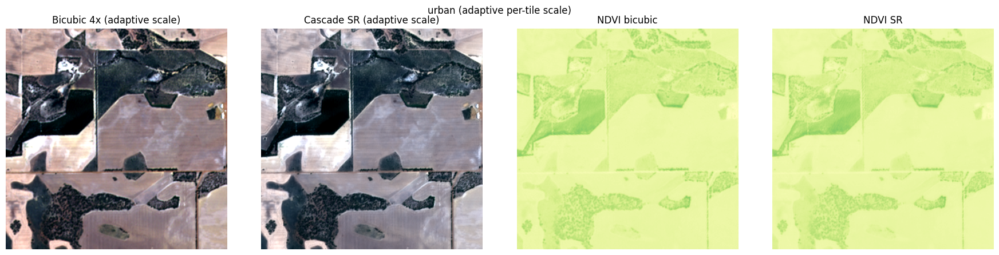

agri local scale (B,G,R,NIR): [3600. 3800. 4200. 5900.]
LR-consistency RMSE -> Cascade: 0.02560 | Bicubic: 0.00582


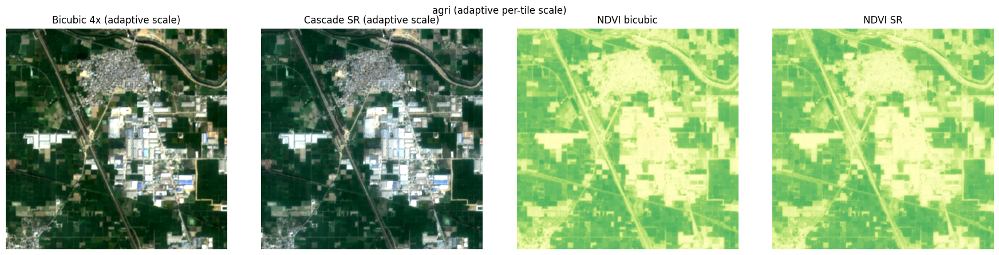

water local scale (B,G,R,NIR): [11400. 11000. 10900. 11900.]
LR-consistency RMSE -> Cascade: 0.01999 | Bicubic: 0.00238


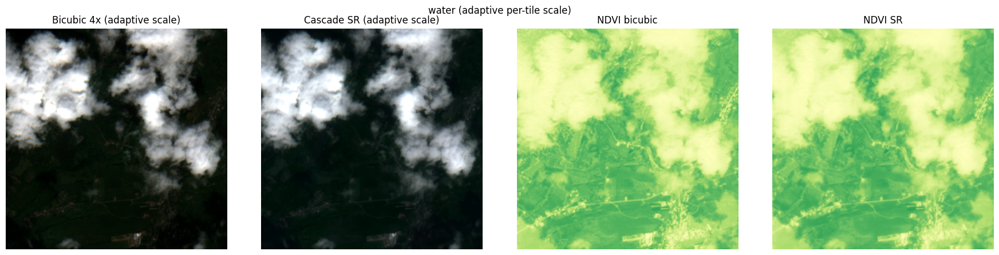

In [19]:
def ndvi_local(img_hwc, scale, eps=1e-6):
    d = img_hwc * scale
    return (d[..., 3] - d[..., 2]) / (d[..., 3] + d[..., 2] + eps)

def disp(x):
    r = x[..., [2,1,0]]; lo, hi = np.percentile(r, 2), np.percentile(r, 98)
    return np.clip((r - lo) / (hi - lo + 1e-6), 0, 1)

def aoi_demo_adaptive(name, tile_path, bands=(1,2,3,4), win=(0,0,256)):
    with rasterio.open(tile_path) as src:
        x0, y0, s = win
        w = Window(x0, y0, min(s, src.width - x0), min(s, src.height - y0))
        arr = src.read(list(bands), window=w).astype(np.float32)

    local_scale = np.ceil(np.percentile(arr.reshape(arr.shape[0], -1), 99.5, axis=1) / 100) * 100
    local_scale = np.maximum(local_scale, 100).astype(np.float32)
    img = np.clip(arr.transpose(1, 2, 0) / local_scale, 0, 1)

    st1, st2 = cascade_tile(model, img, 2)
    bc4 = bicubic_up(img, 4)
    print(f"{name} local scale (B,G,R,NIR): {local_scale}")
    print(f"LR-consistency RMSE -> Cascade: {np.sqrt(np.mean((block_down(st2,4)-img)**2)):.5f} | Bicubic: {np.sqrt(np.mean((block_down(bc4,4)-img)**2)):.5f}")

    n_bc, n_sr = ndvi_local(bc4, local_scale), ndvi_local(st2, local_scale)
    fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))
    ax[0].imshow(disp(bc4)); ax[0].set_title("Bicubic 4x (adaptive scale)")
    ax[1].imshow(disp(st2)); ax[1].set_title("Cascade SR (adaptive scale)")
    ax[2].imshow(n_bc, cmap='RdYlGn', vmin=-1, vmax=1); ax[2].set_title("NDVI bicubic")
    ax[3].imshow(n_sr, cmap='RdYlGn', vmin=-1, vmax=1); ax[3].set_title("NDVI SR")
    for a in ax: a.axis('off')
    plt.suptitle(f"{name} (adaptive per-tile scale)"); plt.tight_layout()
    plt.savefig(f'{WORK}/figures/aoi_{name}_adaptive.png', dpi=150); plt.show()

for name, p in paths.items():
    aoi_demo_adaptive(name, p, bands=(1,2,3,4), win=(0,0,256))

In [20]:
def make_single_geotiff(name, crop_px=2048):
    """Combines the 4 bands from a SAFE folder into a single, labeled, compressed GeoTIFF."""
    folder = f"{WORK}/tiles/{name}_raw"
    b02, b03, b04, b08 = [find_band(folder, b) for b in ("B02", "B03", "B04", "B08")]

    with rasterio.open(b02) as s0:
        if crop_px is None:
            w = Window(0, 0, s0.width, s0.height)
        else:
            w = Window(0, 0, min(crop_px, s0.width), min(crop_px, s0.height))
        crs, tf, dt = s0.crs, s0.window_transform(w), s0.dtypes[0]

    arrs, names = [], ["Blue (B02)", "Green (B03)", "Red (B04)", "NIR (B08)"]
    for p in (b02, b03, b04, b08):
        with rasterio.open(p) as s:
            arrs.append(s.read(1, window=w))

    out_path = f"{WORK}/tiles/{name}_single.tif"
    with rasterio.open(out_path, 'w', driver='GTiff', height=arrs[0].shape[0], width=arrs[0].shape[1],
                        count=4, dtype=dt, crs=crs, transform=tf, compress='deflate') as dst:
        for i, (a, bn) in enumerate(zip(arrs, names), 1):
            dst.write(a, i)
            dst.set_band_description(i, bn)

    size_mb = os.path.getsize(out_path) / 1e6
    print(f"{name}: saved {out_path} | {arrs[0].shape[1]}x{arrs[0].shape[0]} px | {size_mb:.1f} MB")
    return out_path

single_paths = {}
for name in ["urban", "agri", "water"]:
    if os.path.exists(f"{WORK}/tiles/{name}_raw"):
        single_paths[name] = make_single_geotiff(name, crop_px=2048)

urban: saved /content/drive/MyDrive/SIH26142/tiles/urban_single.tif | 2048x2048 px | 27.5 MB
agri: saved /content/drive/MyDrive/SIH26142/tiles/agri_single.tif | 2048x2048 px | 27.9 MB
water: saved /content/drive/MyDrive/SIH26142/tiles/water_single.tif | 2048x2048 px | 28.0 MB


In [21]:
import os, torch, zipfile, numpy as np
from google.colab import files

# 1) Self-contained model bundle (weights + BAND_SCALE + config). Inference will be wrong without BAND_SCALE.
bundle = dict(model=model.state_dict(), band_scale=BAND_SCALE, bands=FINAL_BANDS, scale=SCALE,
              lr_patch=LR_PATCH, history=history, best_val=best)
torch.save(bundle, '/content/model_bundle.pt')
print("Bundle saved:", os.path.getsize('/content/model_bundle.pt') / 1e6, "MB")

# 2) Zip of results + figures + outputs (cache_pairs*.npz files are large, skipped)
with zipfile.ZipFile('/content/results_backup.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for root, _, fs in os.walk(WORK):
        for f in fs:
            if f.startswith('cache_pairs'): continue
            p = os.path.join(root, f); z.write(p, os.path.relpath(p, WORK))
print("Zip saved:", os.path.getsize('/content/results_backup.zip') / 1e6, "MB")

# 3) Download to your computer
files.download('/content/model_bundle.pt')
files.download('/content/results_backup.zip')
print("WORK dir:", WORK)

Bundle saved: 11.657831 MB
Zip saved: 1705.855812 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

WORK dir: /content/drive/MyDrive/SIH26142
